# Extraction temporelle — corpus historique WikiWars

Détection et typage des expressions temporelles (TIMEX3) avec le modèle BERT de Lange et al. (`satyaalmasian/temporal_tagger_BERT_tokenclassifier`), évalués contre les annotations de référence de 4 articles WikiWars. Exécuté sur Kaggle : adapter `base_path` à l'emplacement des fichiers `.sgm` / `.key.xml`.

### Imports

In [ ]:
import os
import sqlite3
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from bs4 import BeautifulSoup
from transformers import pipeline
import logging

logging.getLogger("transformers").setLevel(logging.ERROR)

### Configuration gpu

In [ ]:
device = 0 if torch.cuda.is_available() else -1
print(f"🚀 Accélérateur : {'GPU ' + torch.cuda.get_device_name(0) if device == 0 else 'CPU'}")

🚀 Accélérateur : GPU Tesla P100-PCIE-16GB


### Détection de type à partir de val (iso 8601)

In [ ]:
def determine_type_from_val(val):
    if not val:
        return 'UNKNOWN'
    
    val = str(val).upper().strip()
    
    if val.startswith('P'):
        return 'DURATION'
    
    if 'T' in val:
        t_index = val.index('T')
        after_t = val[t_index+1:] if t_index+1 < len(val) else ''
        
        if after_t:
            if after_t[0].isdigit():
                return 'TIME'
            if len(after_t) >= 2 and after_t[:2] in ['MO', 'AF', 'EV', 'NI']:
                return 'TIME'
    
    if 'XXXX' in val or 'WXX' in val:
        return 'SET'
    
    if '-' in val or (val.isdigit() and len(val) == 4):
        return 'DATE'
    
    return 'UNKNOWN'

### Chargement des données annotées

In [ ]:
def load_wikiwars_data(sgm_path, xml_path):
    print(f"\n📂 Lecture de {os.path.basename(sgm_path)}...")
    
    raw_text = ""
    if os.path.exists(sgm_path):
        try:
            with open(sgm_path, 'r', encoding='utf-8', errors='ignore') as f:
                content = f.read()
            
            # Extraction avec regex
            import re
            match = re.search(r'<TEXT>(.*?)</TEXT>', content, re.DOTALL)
            
            if match:
                raw_text = match.group(1).strip()
            else:
                print(f"⚠️ Aucune balise <TEXT> trouvée dans {os.path.basename(sgm_path)}")
        except Exception as e:
            print(f"⚠️ Erreur SGM: {e}")
    else:
        print(f"⚠️ Fichier SGM introuvable : {sgm_path}")
        
    entities_gold = []
    if os.path.exists(xml_path):
        try:
            with open(xml_path, 'r', encoding='utf-8', errors='ignore') as f:
                content_xml = f.read()
            
            soup_xml = BeautifulSoup(content_xml, 'xml')
            tags = soup_xml.find_all(['TIMEX2', 'timex2', 'TIMEX3', 'timex3'])
            
            for timex in tags:
                val = timex.get('val') or timex.get('value')
                t_type = timex.get('type')
                
                # Si le type n'est pas présent, on l'infère depuis val
                if not t_type:
                    t_type = determine_type_from_val(val)
                
                # Extraction du texte à l'intérieur de la balise TIMEX
                entity_text = timex.get_text().strip()
                
                context = ""
                parent = timex.parent
                if parent:
                    context = parent.get_text().strip()
                    if len(context) > 200:
                        pos = context.find(entity_text)
                        if pos != -1:
                            start = max(0, pos - 50)
                            end = min(len(context), pos + len(entity_text) + 50)
                            context = "..." + context[start:end] + "..."
                        else:
                            context = context[:200] + "..."
                
                entities_gold.append({
                    'text': entity_text,
                    'value': val,
                    'type': t_type,
                    'context': context,
                    'source': 'GOLD'
                })
        except Exception as e:
            print(f"⚠️ Erreur XML: {e}")

    if not entities_gold:
        print("⚠️ Aucune annotation trouvée.")
        df_gold = pd.DataFrame(columns=['text', 'value', 'type', 'context', 'source'])
    else:
        df_gold = pd.DataFrame(entities_gold)
        print(f"✅ {len(df_gold)} entités de référence chargées.")
        
    return raw_text, df_gold

### Extraction via bert

In [ ]:
def extract_temporal_entities_bert(text):
    print("\n🤖 Démarrage du modèle Transformer...")
    
    model_name = "satyaalmasian/temporal_tagger_BERT_tokenclassifier"
    
    try:
        nlp = pipeline("token-classification", 
                       model=model_name, 
                       aggregation_strategy="simple", 
                       device=device, 
                       batch_size=32)
    except Exception as e:
        print(f"⚠️ Modèle spécifique non disponible, repli sur NER standard. ({e})")
        nlp = pipeline("ner", model="dslim/bert-base-NER", aggregation_strategy="simple", device=device, batch_size=32)

    sentences = [s.strip() for s in text.replace('\n', ' ').split('.') if len(s) > 10]
    
    if not sentences:
        return pd.DataFrame(columns=['text', 'type', 'context', 'score', 'sentence_id'])

    print(f"⚡ Analyse de {len(sentences)} phrases en cours...")
    results_list = nlp(sentences)
    
    extracted_entities = []
    
    for sent_id, (sentence, results) in enumerate(zip(sentences, results_list)):
        for ent in results:
            entity_text = ent['word']
            start_pos = sentence.find(entity_text)
            end_pos = start_pos + len(entity_text)
            
            # Phrase complète avec marquage de l'entité
            context = (
                sentence[:start_pos] + 
                f"[{entity_text}]" + 
                sentence[end_pos:]
            )
            
            extracted_entities.append({
                'text': entity_text,
                'type': ent.get('entity_group', 'UNKNOWN'),
                'context': context,
                'score': round(ent['score'], 3),
                'sentence_id': sent_id
            })
    
    if not extracted_entities:
        return pd.DataFrame(columns=['text', 'type', 'context', 'score', 'sentence_id'])
    
    df = pd.DataFrame(extracted_entities)
    print(f"✅ {len(df)} entités extraites par le modèle.")
    return df

### Normalisation des textes pour comparaison

In [ ]:
def normalize_text(text):
    """Normalise le texte pour une comparaison robuste."""
    import re
    text = str(text).lower().strip()
    # Suppression de la ponctuation excessive
    text = re.sub(r'[^\w\s]', '', text)
    # Suppression des espaces multiples
    text = re.sub(r'\s+', ' ', text)
    return text

def texts_match(text1, text2, exact_match=False):
    """Compare deux textes avec option de correspondance floue."""
    norm1 = normalize_text(text1)
    norm2 = normalize_text(text2)
    
    # Correspondance exacte
    if norm1 == norm2:
        return True
    
    # Correspondance souple (l'un contient l'autre)
    if exact_match:
        if norm1 in norm2 or norm2 in norm1:
            return True
    
    return False

### Évaluation 1 : détection d'entités (precision, recall, f1)

In [ ]:
def evaluate_detection(df_gold, df_pred):
    print("\n📊 ÉVALUATION 1 : DÉTECTION D'ENTITÉS")
    print("=" * 60)
    
    if df_gold.empty or df_pred.empty:
        print("⚠️ Impossible de comparer (données manquantes).")
        return 0, 0, 0
    
    golds = df_gold['text'].tolist()
    preds = df_pred['text'].tolist()
    
    tp = 0
    fp = 0
    fn = 0
    
    matched_preds = set()
    
    # Calcul des vrais positifs et faux négatifs
    for g in golds:
        match_found = False
        for i, p in enumerate(preds):
            if i not in matched_preds and texts_match(g, p):
                match_found = True
                matched_preds.add(i)
                break
        if match_found:
            tp += 1
        else:
            fn += 1
    
    # Calcul des faux positifs
    fp = len(preds) - len(matched_preds)
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"🎯 Vrais Positifs (Trouvés) : {tp}")
    print(f"❌ Faux Positifs (Inventés) : {fp}")
    print(f"📉 Faux Négatifs (Oubliés)  : {fn}")
    print("-" * 60)
    print(f"🏆 PRÉCISION : {precision:.2%}")
    print(f"🏆 RAPPEL    : {recall:.2%}")
    print(f"🏆 F1-SCORE  : {f1:.2%}")
    print("=" * 60)
    
    return precision, recall, f1

### Évaluation 2 : classification de type (precision, recall, f1)

In [ ]:
def evaluate_classification(df_gold, df_pred):
    print("\n📊 ÉVALUATION 2 : CLASSIFICATION DES TYPES")
    print("=" * 60)
    
    if df_gold.empty or df_pred.empty:
        print("⚠️ Impossible de comparer (données manquantes).")
        return 0, 0, 0
    
    golds = [(row['text'], row['type']) for _, row in df_gold.iterrows()]
    preds = [(row['text'], row['type']) for _, row in df_pred.iterrows()]
    
    tp_type = 0
    fp_type = 0
    fn_type = 0
    
    matched_pairs = []
    matched_preds = set()
    
    # Calcul des types corrects et incorrects
    for g_text, g_type in golds:
        match_found = False
        for i, (p_text, p_type) in enumerate(preds):
            if i not in matched_preds and texts_match(g_text, p_text):
                match_found = True
                matched_preds.add(i)
                matched_pairs.append((g_text, g_type, p_type))
                if g_type == p_type:
                    tp_type += 1
                else:
                    fp_type += 1
                break
        
        if not match_found:
            fn_type += 1
    
    precision_type = tp_type / (tp_type + fp_type) if (tp_type + fp_type) > 0 else 0
    recall_type = tp_type / (tp_type + fn_type) if (tp_type + fn_type) > 0 else 0
    f1_type = 2 * (precision_type * recall_type) / (precision_type + recall_type) if (precision_type + recall_type) > 0 else 0
    
    print(f"🎯 Types Corrects : {tp_type}")
    print(f"❌ Types Incorrects : {fp_type}")
    print(f"📉 Entités Non Détectées : {fn_type}")
    print("-" * 60)
    print(f"🏆 PRÉCISION (Type) : {precision_type:.2%}")
    print(f"🏆 RAPPEL (Type)    : {recall_type:.2%}")
    print(f"🏆 F1-SCORE (Type)  : {f1_type:.2%}")
    print("=" * 60)
    
    if fp_type > 0:
        print("\n📋 Exemples d'erreurs de classification:")
        error_count = 0
        for g_text, g_type, p_type in matched_pairs:
            if g_type != p_type and error_count < 5:
                print(f"  • '{g_text[:50]}...' : {p_type} (prédit) vs {g_type} (gold)")
                error_count += 1
        print()
    
    return precision_type, recall_type, f1_type

### Visualisation des résultats

In [ ]:
def plot_comprehensive_statistics(df_gold, df_pred, sgm_name, det_scores, clf_scores):
    print("\n📈 Génération des graphiques...")
    
    fig = plt.figure(figsize=(18, 10))
    
    # Graphique 1: Distribution des types
    ax1 = plt.subplot(2, 3, 1)
    data_dict = {}
    if not df_gold.empty:
        data_dict['Gold'] = df_gold['type'].value_counts()
    if not df_pred.empty:
        data_dict['Prédit'] = df_pred['type'].value_counts()
    
    df_plot = pd.DataFrame(data_dict).fillna(0)
    if not df_plot.empty:
        df_plot.plot(kind='bar', ax=ax1, color=['#2ecc71', '#3498db'])
        ax1.set_title("Distribution des Types d'Entités", fontsize=12, fontweight='bold')
        ax1.set_xlabel("Type")
        ax1.set_ylabel("Nombre")
        ax1.legend(loc='best')
        plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # Graphique 2: Scores de détection
    ax2 = plt.subplot(2, 3, 2)
    det_metrics = ['Précision', 'Rappel', 'F1-Score']
    det_values = [det_scores[0], det_scores[1], det_scores[2]]
    colors = ['#e74c3c', '#f39c12', '#9b59b6']
    bars = ax2.bar(det_metrics, det_values, color=colors, alpha=0.7)
    ax2.set_title("Scores de Détection d'Entités", fontsize=12, fontweight='bold')
    ax2.set_ylabel("Score")
    ax2.set_ylim(0, 1)
    for bar, val in zip(bars, det_values):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.1%}', ha='center', va='bottom', fontweight='bold')
    
    # Graphique 3: Scores de classification
    ax3 = plt.subplot(2, 3, 3)
    clf_metrics = ['Précision', 'Rappel', 'F1-Score']
    clf_values = [clf_scores[0], clf_scores[1], clf_scores[2]]
    bars = ax3.bar(clf_metrics, clf_values, color=colors, alpha=0.7)
    ax3.set_title("Scores de Classification des Types", fontsize=12, fontweight='bold')
    ax3.set_ylabel("Score")
    ax3.set_ylim(0, 1)
    for bar, val in zip(bars, clf_values):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.1%}', ha='center', va='bottom', fontweight='bold')
    
    # Graphique 4: Distribution des scores de confiance
    ax4 = plt.subplot(2, 3, 4)
    if not df_pred.empty and 'score' in df_pred.columns:
        sns.histplot(df_pred['score'], bins=15, kde=True, color='#8e44ad', ax=ax4)
        ax4.set_title("Distribution des Scores de Confiance", fontsize=12, fontweight='bold')
        ax4.set_xlabel("Score de Confiance")
        ax4.set_ylabel("Fréquence")
    
    # Graphique 5: Comparaison Détection vs Classification
    ax5 = plt.subplot(2, 3, 5)
    comparison_data = {
        'Détection': det_values,
        'Classification': clf_values
    }
    df_comparison = pd.DataFrame(comparison_data, index=det_metrics)
    df_comparison.plot(kind='bar', ax=ax5, color=['#16a085', '#d35400'])
    ax5.set_title("Comparaison Détection vs Classification", fontsize=12, fontweight='bold')
    ax5.set_ylabel("Score")
    ax5.set_ylim(0, 1)
    ax5.legend(loc='best')
    plt.setp(ax5.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # Graphique 6: Matrice de confusion simplifiée
    ax6 = plt.subplot(2, 3, 6)
    if not df_gold.empty and not df_pred.empty:
        golds = df_gold['text'].tolist()
        preds = df_pred['text'].tolist()
        
        matched_preds = set()
        tp = 0
        for g in golds:
            for i, p in enumerate(preds):
                if i not in matched_preds and texts_match(g, p):
                    tp += 1
                    matched_preds.add(i)
                    break
        
        fp = len(preds) - len(matched_preds)
        fn = len(golds) - tp
        tn = 0
        
        confusion_data = [[tp, fp], [fn, tn]]
        sns.heatmap(confusion_data, annot=True, fmt='d', cmap='Blues', ax=ax6,
                   xticklabels=['Positif', 'Négatif'],
                   yticklabels=['Vrai', 'Faux'])
        ax6.set_title("Matrice de Confusion (Détection)", fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    output_path = f'stats_{sgm_name}.png'
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    print(f"✅ Graphiques sauvegardés: {output_path}")
    plt.show()

### Matching entre prédictions et gold standard

In [ ]:
def match_predictions_to_gold(df_pred, df_gold):
    """
    Crée un DataFrame enrichi avec les correspondances entre prédictions et gold standard.
    """
    results = []
    
    if df_pred.empty and df_gold.empty:
        return pd.DataFrame()
    
    matched_gold_indices = set()
    matched_pred_indices = set()
    
    # 1. Traiter les prédictions qui matchent avec le gold
    for pred_idx, pred_row in df_pred.iterrows():
        pred_text = pred_row['text']
        pred_type = pred_row['type']
        pred_context = pred_row.get('context', '')
        
        match_found = False
        gold_text = None
        gold_type = None
        gold_value = None
        entity_matched = False
        type_matched = False
        
        # Chercher une correspondance dans le gold
        for gold_idx, gold_row in df_gold.iterrows():
            if gold_idx not in matched_gold_indices:
                if texts_match(pred_text, gold_row['text']):
                    match_found = True
                    matched_gold_indices.add(gold_idx)
                    matched_pred_indices.add(pred_idx)
                    
                    gold_text = gold_row['text']
                    gold_type = gold_row['type']
                    gold_value = gold_row.get('value', None)
                    entity_matched = True
                    type_matched = (pred_type == gold_type)
                    break
        
        # Si aucun match trouvé, c'est un faux positif (entité inventée)
        if not match_found:
            gold_text = "N/A (Inventée)"
            gold_type = "N/A"
            gold_value = "N/A"
            entity_matched = False
            type_matched = False
        
        results.append({
            'predicted_text': pred_text,
            'predicted_type': pred_type,
            'predicted_context': pred_context,
            'gold_text': gold_text,
            'gold_type': gold_type,
            'gold_value': gold_value,
            'entity_matched': entity_matched,
            'type_matched': type_matched,
            'status': 'TRUE_POSITIVE' if entity_matched else 'FALSE_POSITIVE'
        })
    
    # 2. Traiter les entités gold qui n'ont pas été détectées (faux négatifs)
    for gold_idx, gold_row in df_gold.iterrows():
        if gold_idx not in matched_gold_indices:
            results.append({
                'predicted_text': "N/A (Oubliée)",
                'predicted_type': "N/A",
                'predicted_context': gold_row.get('context', ''),
                'gold_text': gold_row['text'],
                'gold_type': gold_row['type'],
                'gold_value': gold_row.get('value', None),
                'entity_matched': False,
                'type_matched': False,
                'status': 'FALSE_NEGATIVE'
            })
    
    return pd.DataFrame(results)

### Export vers base de données unifiée

In [ ]:
def export_to_unified_db(df_pred, df_gold, table_name, db_name="projet_temporel_unifie.db"):
    print(f"\n💾 Sauvegarde dans la base unifiée : {db_name}")
    print(f"📊 Table : {table_name}")
    
    # Créer le DataFrame enrichi avec les matchs
    df_enriched = match_predictions_to_gold(df_pred, df_gold)
    
    if df_enriched.empty:
        print("⚠️ Aucune entité à sauvegarder.")
        return
    
    conn = sqlite3.connect(db_name)
    c = conn.cursor()
    
    c.execute(f'''
        CREATE TABLE IF NOT EXISTS `{table_name}` (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            predicted_text TEXT,
            predicted_type TEXT,
            predicted_context TEXT,
            gold_text TEXT,
            gold_type TEXT,
            gold_value TEXT,
            entity_matched BOOLEAN,
            type_matched BOOLEAN,
            status TEXT
        )
    ''')
    
    for _, row in df_enriched.iterrows():
        c.execute(f'''
            INSERT INTO `{table_name}` 
            (predicted_text, predicted_type, predicted_context, 
             gold_text, gold_type, gold_value,
             entity_matched, type_matched, status)
            VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?)
        ''', (
            row['predicted_text'],
            row['predicted_type'],
            row['predicted_context'],
            row['gold_text'],
            row['gold_type'],
            row['gold_value'],
            row['entity_matched'],
            row['type_matched'],
            row['status']
        ))
    
    conn.commit()
    
    c.execute(f'SELECT COUNT(*) FROM `{table_name}`')
    count = c.fetchone()[0]
    print(f"✅ {count} lignes insérées dans la table '{table_name}'")
    
    # Statistiques
    c.execute(f'''
        SELECT 
            SUM(CASE WHEN status = 'TRUE_POSITIVE' THEN 1 ELSE 0 END) as tp,
            SUM(CASE WHEN status = 'FALSE_POSITIVE' THEN 1 ELSE 0 END) as fp,
            SUM(CASE WHEN status = 'FALSE_NEGATIVE' THEN 1 ELSE 0 END) as fn,
            SUM(CASE WHEN entity_matched = 1 AND type_matched = 1 THEN 1 ELSE 0 END) as correct_types
        FROM `{table_name}`
    ''')
    stats = c.fetchone()
    print(f"\n📊 Statistiques de la table:")
    print(f"  • Vrais Positifs (détectés correctement) : {stats[0]}")
    print(f"  • Faux Positifs (inventées) : {stats[1]}")
    print(f"  • Faux Négatifs (oubliées) : {stats[2]}")
    print(f"  • Types correctement classifiés : {stats[3]}")
    
    print("\n📋 Aperçu:")
    df_sample = pd.read_sql_query(f"SELECT * FROM `{table_name}` LIMIT 5", conn)
    print(df_sample.to_string(index=False))
    
    conn.close()

### Affichage du contenu de la base

In [ ]:
def display_unified_database(db_name="projet_temporel_unifie.db"):
    if not os.path.exists(db_name):
        print(f"⚠️ Base de données '{db_name}' introuvable.")
        return
    
    conn = sqlite3.connect(db_name)
    c = conn.cursor()
    
    c.execute("SELECT name FROM sqlite_master WHERE type='table'")
    tables = c.fetchall()
    
    print(f"\n📊 CONTENU DE LA BASE UNIFIÉE : {db_name}")
    print("=" * 80)
    print(f"Nombre de tables : {len(tables)}")
    print("\nTables disponibles :")
    for table in tables:
        table_name = table[0]
        c.execute(f"SELECT COUNT(*) FROM `{table_name}`")
        count = c.fetchone()[0]
        print(f"  • {table_name} : {count} entités")
    
    print("\n" + "=" * 80)
    
    for table in tables:
        table_name = table[0]
        print(f"\n📋 Aperçu de '{table_name}':")
        df = pd.read_sql_query(f"SELECT * FROM `{table_name}` LIMIT 3", conn)
        if not df.empty:
            print(df.to_string(index=False))
        else:
            print("  (Vide)")
        print("-" * 80)
    
    conn.close()

### Pipeline principal

In [ ]:
def extract_and_evaluate(sgm_path, xml_path, base_path="/kaggle/input/wikiwars/"):
    file_sgm = base_path + sgm_path
    file_xml = base_path + xml_path
    
    sgm_name = os.path.splitext(os.path.basename(sgm_path))[0]
    table_name = sgm_name.replace('-', '_').replace(' ', '_')
    
    print("\n" + "=" * 80)
    print(f"🚀 TRAITEMENT : {sgm_name}")
    print("=" * 80)
    
    text, df_gold = load_wikiwars_data(file_sgm, file_xml)
    
    df_pred = extract_temporal_entities_bert(text)
    
    det_scores = evaluate_detection(df_gold, df_pred)
    clf_scores = evaluate_classification(df_gold, df_pred)
    
    plot_comprehensive_statistics(df_gold, df_pred, sgm_name, det_scores, clf_scores)
    
    export_to_unified_db(df_pred, df_gold, table_name)
    
    print("\n" + "=" * 80)
    print(f"✅ TRAITEMENT TERMINÉ : {sgm_name}")
    print("=" * 80)
    
    return det_scores, clf_scores

## 🎯 Exécution du Pipeline

Le code ci-dessous traite tous les documents et génère:
- Une base de données unifiée `projet_temporel_unifie.db`
- Des graphiques pour chaque document
- Un résumé global des performances


🚀 TRAITEMENT : 17_AlgerianWar

📂 Lecture de 17_AlgerianWar.sgm...
✅ 130 entités de référence chargées.

🤖 Démarrage du modèle Transformer...
⚡ Analyse de 259 phrases en cours...
✅ 129 entités extraites par le modèle.

📊 ÉVALUATION 1 : DÉTECTION D'ENTITÉS
🎯 Vrais Positifs (Trouvés) : 123
❌ Faux Positifs (Inventés) : 6
📉 Faux Négatifs (Oubliés)  : 7
------------------------------------------------------------
🏆 PRÉCISION : 95.35%
🏆 RAPPEL    : 94.62%
🏆 F1-SCORE  : 94.98%

📊 ÉVALUATION 2 : CLASSIFICATION DES TYPES
🎯 Types Corrects : 108
❌ Types Incorrects : 15
📉 Entités Non Détectées : 7
------------------------------------------------------------
🏆 PRÉCISION (Type) : 87.80%
🏆 RAPPEL (Type)    : 93.91%
🏆 F1-SCORE (Type)  : 90.76%

📋 Exemples d'erreurs de classification:
  • 'only a few months before...' : DATE (prédit) vs SET (gold)
  • 'a long time...' : DATE (prédit) vs UNKNOWN (gold)
  • 'the past...' : DATE (prédit) vs DURATION (gold)
  • 'now...' : DATE (prédit) vs DURATION (gold)
 

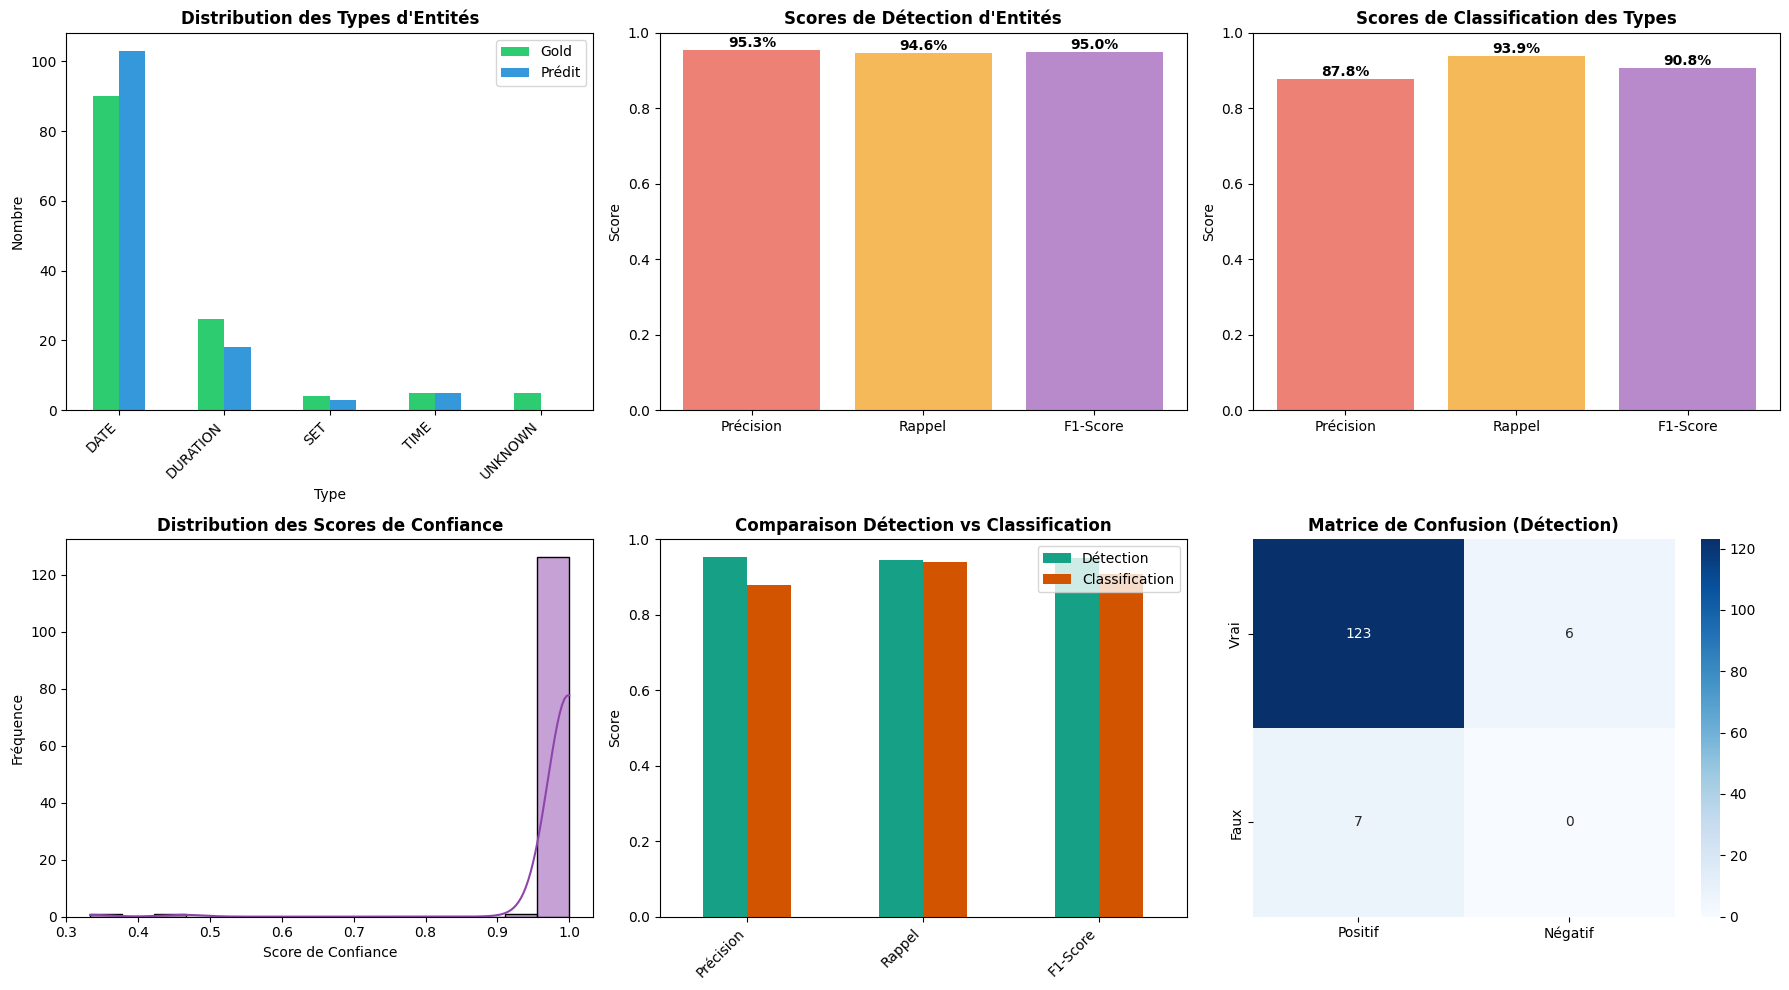


💾 Sauvegarde dans la base unifiée : projet_temporel_unifie.db
📊 Table : 17_AlgerianWar
✅ 268 lignes insérées dans la table '17_AlgerianWar'

📊 Statistiques de la table:
  • Vrais Positifs (détectés correctement) : 250
  • Faux Positifs (inventées) : 8
  • Faux Négatifs (oubliées) : 10
  • Types correctement classifiés : 216

📋 Aperçu:
 id                              predicted_text predicted_type                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              predicted_

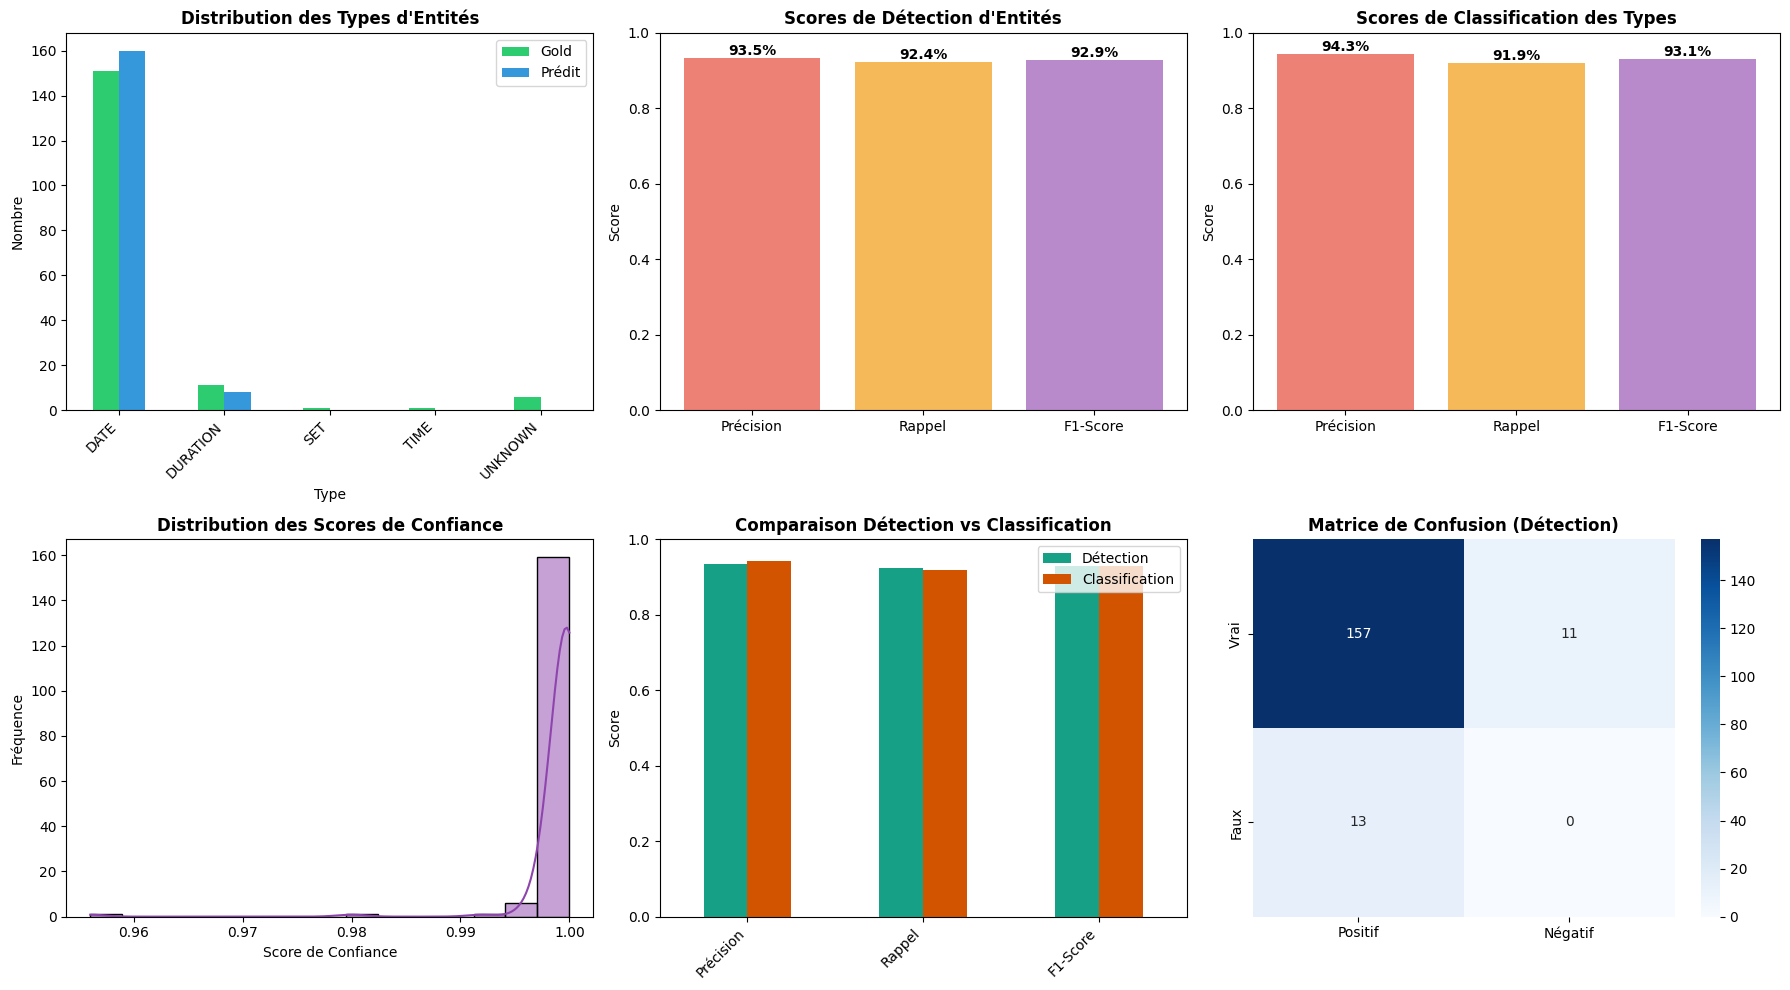


💾 Sauvegarde dans la base unifiée : projet_temporel_unifie.db
📊 Table : 01_WW2
✅ 357 lignes insérées dans la table '01_WW2'

📊 Statistiques de la table:
  • Vrais Positifs (détectés correctement) : 319
  • Faux Positifs (inventées) : 17
  • Faux Négatifs (oubliées) : 21
  • Types correctement classifiés : 301

📋 Aperçu:
 id                        predicted_text predicted_type                                                                                                                                                                                                                                                                                                                                                                                                                                      predicted_context                             gold_text gold_type gold_value  entity_matched  type_matched        status
  1                     september 1, 1939           DATE                      

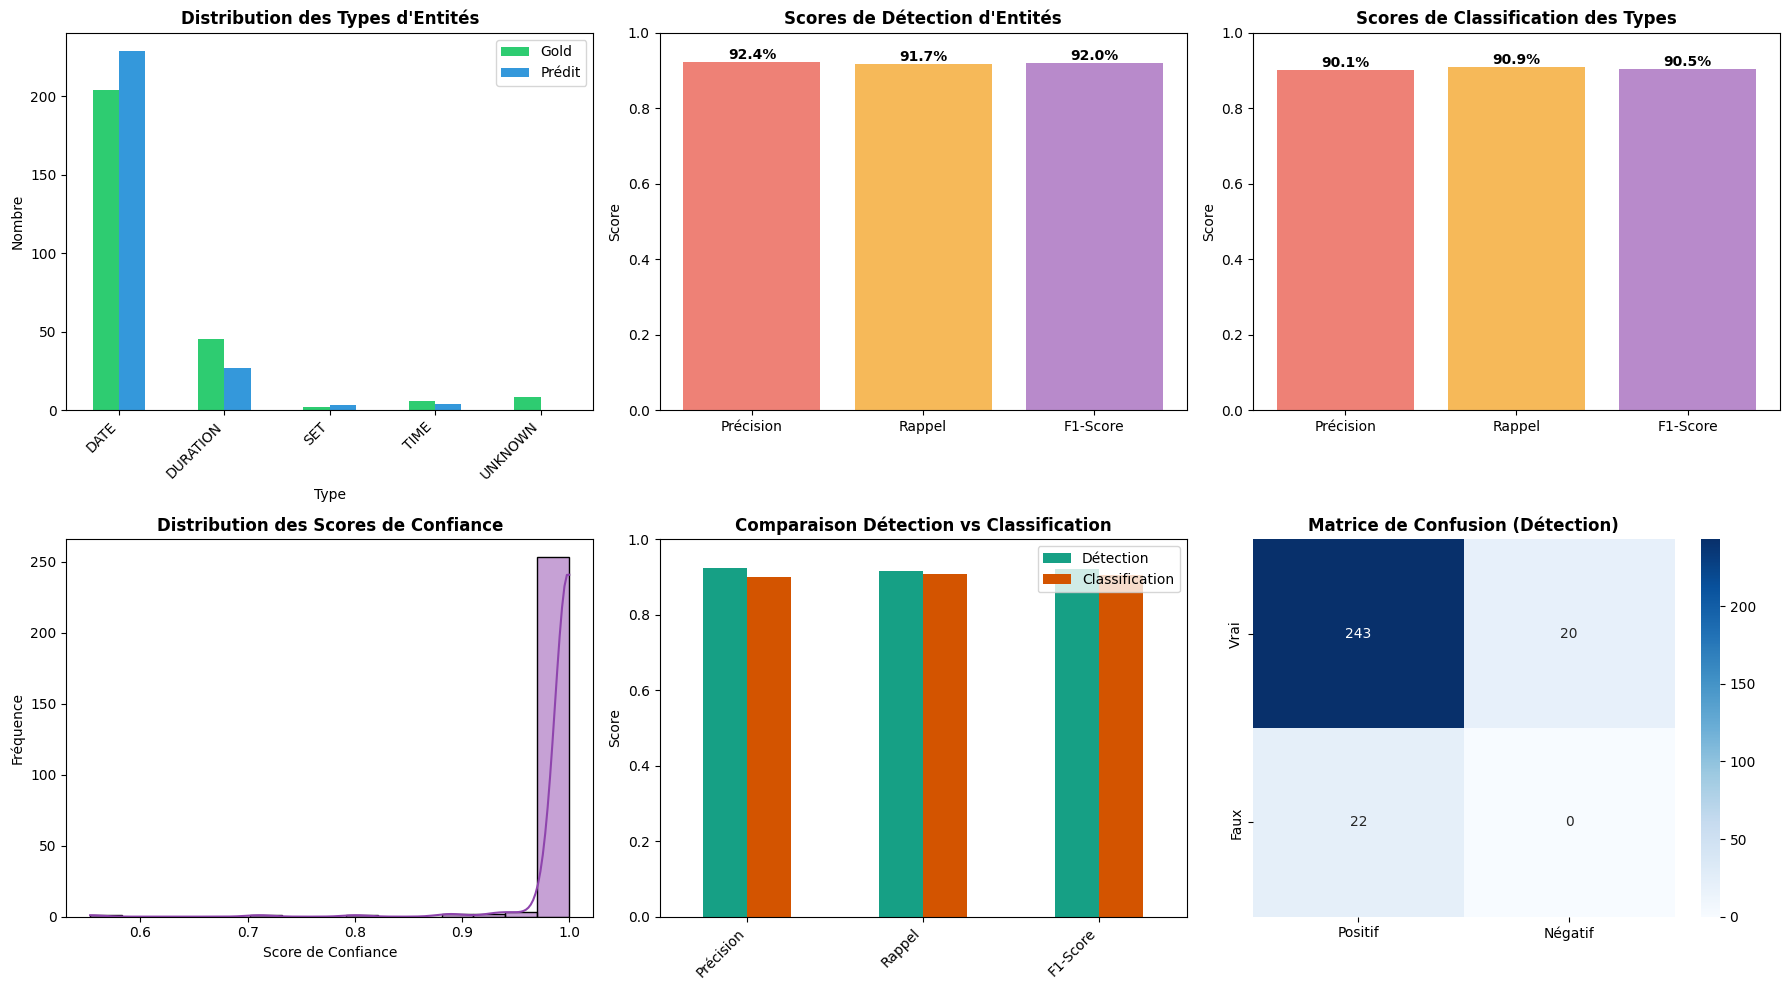


💾 Sauvegarde dans la base unifiée : projet_temporel_unifie.db
📊 Table : 02_WW1
✅ 557 lignes insérées dans la table '02_WW1'

📊 Statistiques de la table:
  • Vrais Positifs (détectés correctement) : 499
  • Faux Positifs (inventées) : 27
  • Faux Négatifs (oubliées) : 31
  • Types correctement classifiés : 448

📋 Aperçu:
 id              predicted_text predicted_type                                                                                                                                                                                                                                                                                                                                                                                                                                                                  predicted_context                   gold_text gold_type gold_value  entity_matched  type_matched        status
  1               early in 1914           DATE                        

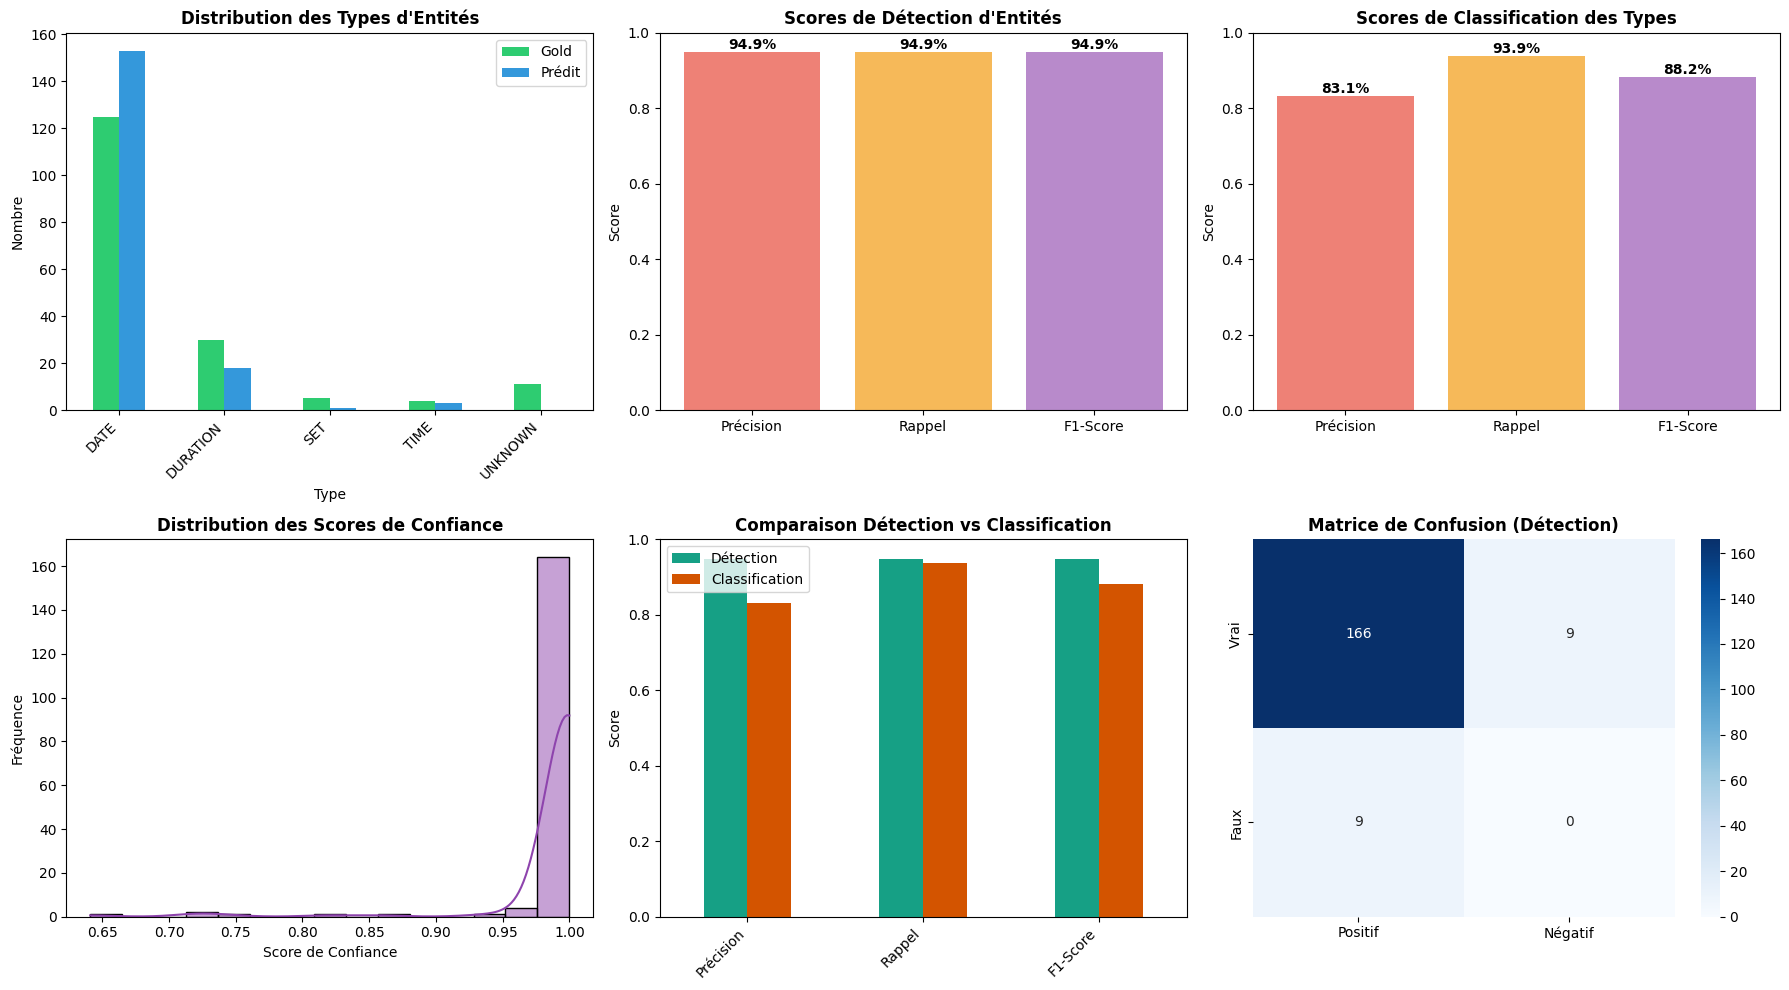


💾 Sauvegarde dans la base unifiée : projet_temporel_unifie.db
📊 Table : 08_FrenchRev
✅ 363 lignes insérées dans la table '08_FrenchRev'

📊 Statistiques de la table:
  • Vrais Positifs (détectés correctement) : 337
  • Faux Positifs (inventées) : 13
  • Faux Négatifs (oubliées) : 13
  • Types correctement classifiés : 279

📋 Aperçu:
 id predicted_text predicted_type                                                                                                                                                                                                                                                                                                                                                                                                                                  predicted_context     gold_text gold_type gold_value  entity_matched  type_matched        status
  1    seven years       DURATION                                                                                    

In [ ]:
files = [
    ("17_AlgerianWar.sgm", "17_AlgerianWar.key.xml"),
    ("01_WW2.sgm", "01_WW2.key.xml"),
    ("02_WW1.sgm", "02_WW1.key.xml"),
    ("08_FrenchRev.sgm", "08_FrenchRev.key.xml")
]

all_results = []

for sgm, xml in files:
    det_scores, clf_scores = extract_and_evaluate(sgm, xml)
    all_results.append({
        'fichier': os.path.splitext(sgm)[0],
        'det_precision': det_scores[0],
        'det_recall': det_scores[1],
        'det_f1': det_scores[2],
        'clf_precision': clf_scores[0],
        'clf_recall': clf_scores[1],
        'clf_f1': clf_scores[2]
    })

print("\n" + "=" * 80)
print("📊 RÉSUMÉ GLOBAL DES RÉSULTATS")
print("=" * 80)
df_summary = pd.DataFrame(all_results)
print(df_summary.to_string(index=False))

print("\n📊 Moyennes globales:")
print(f"  Détection    - Précision: {df_summary['det_precision'].mean():.2%}, "
      f"Rappel: {df_summary['det_recall'].mean():.2%}, "
      f"F1: {df_summary['det_f1'].mean():.2%}")
print(f"  Classification - Précision: {df_summary['clf_precision'].mean():.2%}, "
      f"Rappel: {df_summary['clf_recall'].mean():.2%}, "
      f"F1: {df_summary['clf_f1'].mean():.2%}")

display_unified_database()

print("\n" + "=" * 80)
print("✅ PIPELINE COMPLET TERMINÉ AVEC SUCCÈS")
print("=" * 80)